# User Behaviour Encoder — Next-Action Prediction & Embedding Similarity

## Goal
Train a sequence model (LSTM and Transformer) on users' event streams using **next-action prediction** as the self-supervised training objective.  
After training the model learns the grammar of each user's behaviour. We extract the **final hidden state** (LSTM) or **mean-pooled output** (Transformer) as a dense user embedding vector, then search for similar users via cosine similarity.

## Mental model
```
Event stream (per user):
  session_start → search_query → document_view → alert_create → session_end → …

                     ↓  treat as a sequence language model

Next-action prediction:
  [session_start]              → predict: search_query
  [session_start, search_query] → predict: document_view
  …

                     ↓  after training

User embedding:  final hidden state  →  cosine similarity  →  find similar users
```

## Key design decisions
| Decision | Choice | Rationale |
|---|---|---|
| Token vocabulary | 13 event types + PAD + BOS | Small, interpretable |
| Training objective | Next-event prediction (causal LM) | Forces model to learn transition patterns |
| Data augmentation | Sliding-window over each user's sequence | Turns 10 × 50 events into ~400 training pairs |
| User embedding | Final LSTM hidden state / mean-pool Transformer output | Summarises the full behavioural trajectory |
| Similarity metric | Cosine similarity | Scale-invariant, standard for embedding spaces |

## Block 1 — Imports & Reproducibility

In [1]:
import ast
import math
import random
import time
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: mps
PyTorch: 2.12.0


## Block 2 — Load & Inspect Raw Event Data

We load `amplitude_events.csv` and immediately characterise the schema so there are no surprises during modelling.

Key columns we care about:
| Column | Role |
|---|---|
| `user_id` | Groups events into per-user sequences |
| `event_type` | The token we will model |
| `sequence_number` | Defines the temporal order within a user |
| `user_properties` | Persona metadata — used as ground truth labels for embedding evaluation |

In [2]:
DATA_PATH = Path("data_gen/output/amplitude_events.csv")
df = pd.read_csv(DATA_PATH)

print(f"Shape            : {df.shape}")
print(f"Columns          : {df.columns.tolist()}")
print(f"Unique users     : {df['user_id'].nunique()}")
print(f"Unique event types: {df['event_type'].nunique()}")
print(f"Date range       : {df['event_time'].min()} → {df['event_time'].max()}")
print()
print("Missing values:")
print(df.isnull().sum())
print()
df.head(5)

Shape            : (500, 13)
Columns          : ['user_id', 'amplitude_id', 'event_type', 'event_time', 'session_id', 'device_type', 'os_name', 'platform', 'country', 'city', 'event_properties', 'user_properties', 'sequence_number']
Unique users     : 10
Unique event types: 13
Date range       : 2026-02-17T01:46:17Z → 2026-05-15T08:16:31Z

Missing values:
user_id             0
amplitude_id        0
event_type          0
event_time          0
session_id          0
device_type         0
os_name             0
platform            0
country             0
city                0
event_properties    0
user_properties     0
sequence_number     0
dtype: int64



,user_id,amplitude_id,event_type,event_time,session_id,device_type,os_name,platform,country,city,event_properties,user_properties,sequence_number
0,usr_0006,4200006,session_start,2026-02-17T01:46:17Z,1611120089,Desktop,Windows,Bloomberg Terminal,United States,Chicago,"{""login_method"": ""biometric""}","{""persona"": ""tax_technology_manager"", ""org_typ...",0
1,usr_0006,4200006,function_run,2026-02-17T01:49:47Z,1611120089,Desktop,macOS,Bloomberg Terminal,United States,Chicago,"{""function_code"": ""TAX Network"", ""input_params...","{""persona"": ""tax_technology_manager"", ""org_typ...",1
2,usr_0006,4200006,search_query,2026-02-17T01:50:00Z,1611120089,Desktop,Windows,Bloomberg Terminal,United States,Chicago,"{""query_text"": ""GAAP vs. tax reporting standar...","{""persona"": ""tax_technology_manager"", ""org_typ...",2
3,usr_0006,4200006,document_view,2026-02-17T01:51:04Z,1611120089,Desktop,macOS,Bloomberg Terminal,United States,Chicago,"{""doc_id"": ""DOC-84055"", ""doc_type"": ""treaty"", ...","{""persona"": ""tax_technology_manager"", ""org_typ...",3
4,usr_0006,4200006,session_end,2026-02-17T01:51:10Z,1611120089,Desktop,Windows,Bloomberg Terminal,United States,Chicago,"{""duration_seconds"": 3727, ""logout_type"": ""idle""}","{""persona"": ""tax_technology_manager"", ""org_typ...",4


In [3]:
# Parse user_properties JSON column → flat persona columns
df["user_props"] = df["user_properties"].apply(ast.literal_eval)
df["persona"]    = df["user_props"].apply(lambda x: x.get("persona", "unknown"))
df["org_type"]   = df["user_props"].apply(lambda x: x.get("org_type", "unknown"))
df["firm_size"]  = df["user_props"].apply(lambda x: x.get("firm_size", "unknown"))
df["years_exp"]  = df["user_props"].apply(lambda x: x.get("years_experience", -1))

# Persona per user (stable, one row per user)
user_meta = df.drop_duplicates("user_id")[["user_id", "persona", "org_type", "firm_size", "years_exp"]].set_index("user_id")
print("User personas:")
print(user_meta.to_string())

User personas:
                              persona                  org_type firm_size  years_exp
user_id                                                                             
usr_0006       tax_technology_manager           consulting firm    medium          8
usr_0000           senior_tax_partner            large law firm     large         22
usr_0004            ma_tax_specialist           investment bank     large         10
usr_0002          inhouse_tax_counsel   Fortune 500 corporation     large         12
usr_0003         tax_research_analyst   financial research firm    medium          7
usr_0008                tax_litigator  boutique litigation firm     small         10
usr_0007           compliance_officer     financial institution    medium         10
usr_0001         junior_tax_associate            large law firm     large          3
usr_0009     estate_planning_attorney       private wealth firm     small         12
usr_0005  transfer_pricing_specialist     Big 4 ac

## Block 3 — Exploratory Data Analysis

Before modelling we need to understand:
1. **Event distribution** — is the vocabulary skewed? (affects what the model sees most)
2. **Sequence length per user** — are sequences homogeneous or variable?
3. **Per-user event mix** — do different personas exhibit visibly different behaviours? (validates that embeddings *should* separate them)

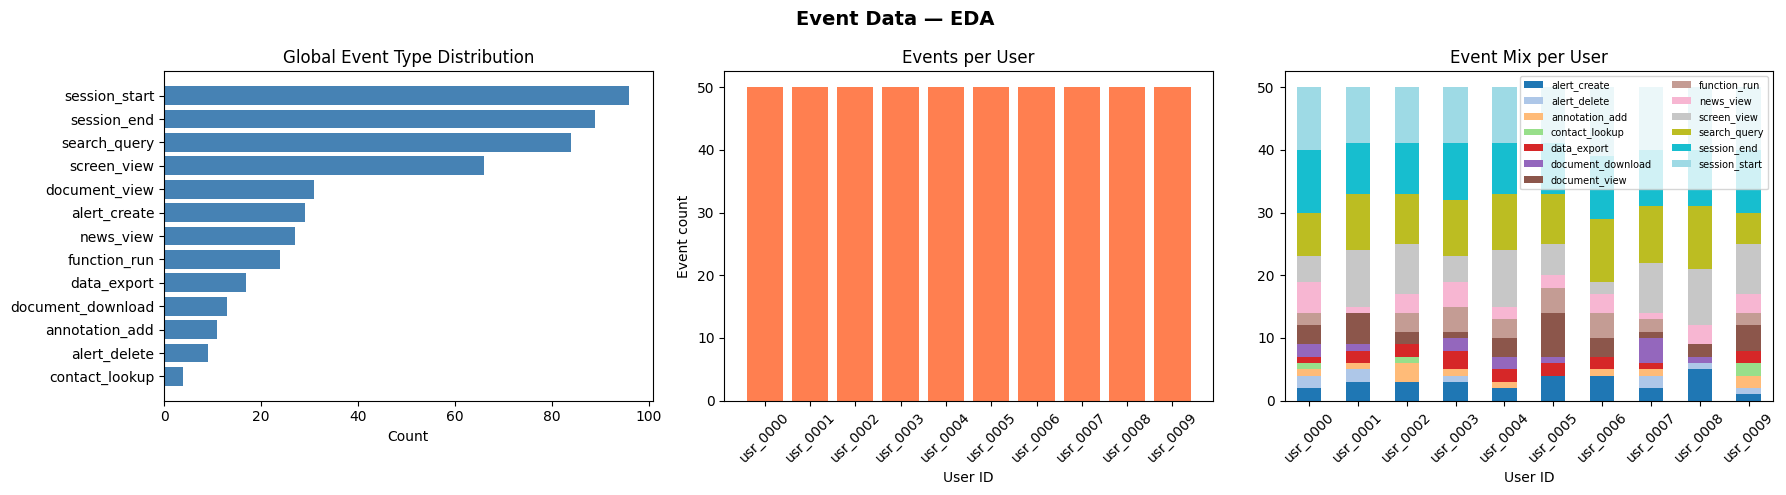


Event type value counts:
event_type
session_start        96
session_end          89
search_query         84
screen_view          66
document_view        31
alert_create         29
news_view            27
function_run         24
data_export          17
document_download    13
annotation_add       11
alert_delete          9
contact_lookup        4

Events per user: mean=50.0, std=0.0, min=50, max=50


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Event Data — EDA", fontsize=14, fontweight="bold")

# ── 1. Global event type distribution ─────────────────────────────────────────
event_counts = df["event_type"].value_counts()
axes[0].barh(event_counts.index, event_counts.values, color="steelblue")
axes[0].set_title("Global Event Type Distribution")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# ── 2. Events per user ─────────────────────────────────────────────────────────
events_per_user = df.groupby("user_id").size()
axes[1].bar(events_per_user.index, events_per_user.values, color="coral")
axes[1].set_title("Events per User")
axes[1].set_xlabel("User ID")
axes[1].set_ylabel("Event count")
axes[1].tick_params(axis="x", rotation=45)

# ── 3. Per-user event mix (stacked bar) ───────────────────────────────────────
pivot = df.groupby(["user_id", "event_type"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", stacked=True, ax=axes[2], legend=True, colormap="tab20")
axes[2].set_title("Event Mix per User")
axes[2].set_xlabel("User ID")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(loc="upper right", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
print("\nEvent type value counts:")
print(event_counts.to_string())
print(f"\nEvents per user: mean={events_per_user.mean():.1f}, std={events_per_user.std():.1f}, min={events_per_user.min()}, max={events_per_user.max()}")

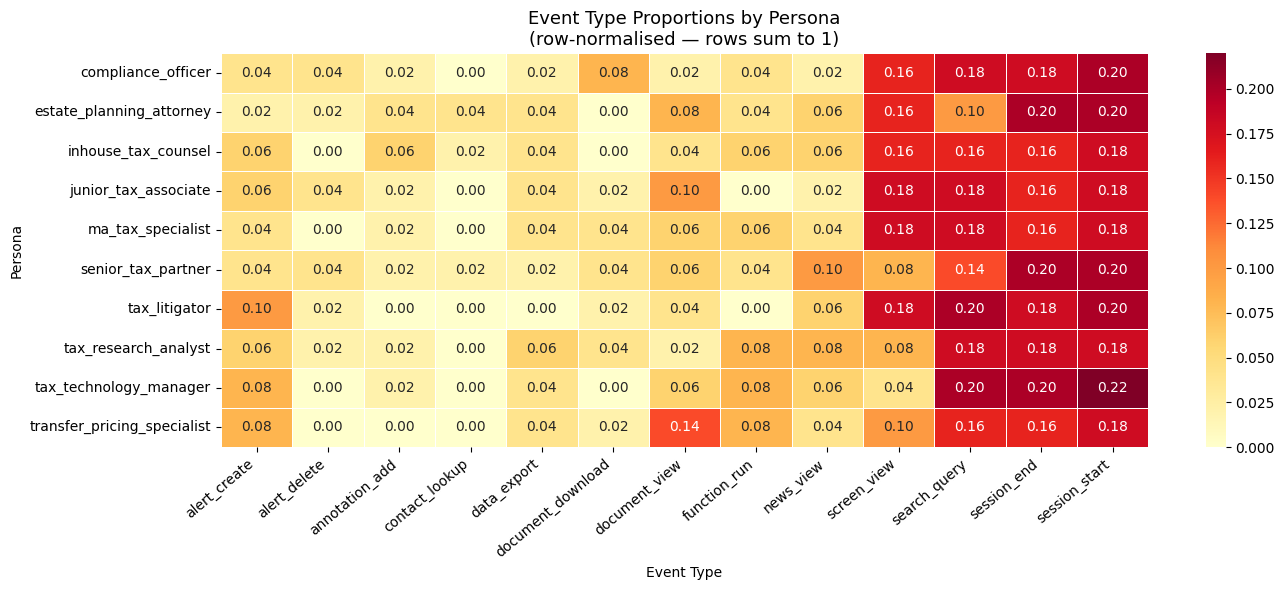


Key takeaway: if rows look visibly different, the model has a real signal to learn.
Personas with similar rows will naturally cluster together in embedding space.


In [6]:
# ── Per-persona event heatmap ──────────────────────────────────────────────────
# Shows whether different personas have visibly different behavioural fingerprints
df_merged = df  # df already has 'persona' column from the user_properties parse above
heatmap_data = df_merged.groupby(["persona", "event_type"]).size().unstack(fill_value=0)

# Normalise per persona so we see proportions, not raw counts
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_norm, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Event Type Proportions by Persona\n(row-normalised — rows sum to 1)", fontsize=13)
plt.xlabel("Event Type")
plt.ylabel("Persona")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("\nKey takeaway: if rows look visibly different, the model has a real signal to learn.")
print("Personas with similar rows will naturally cluster together in embedding space.")

## Block 4 — Vocabulary & Tokenisation

### What we build
- A **token → integer** mapping for all 13 event types
- Three special tokens: `<PAD>` (0), `<BOS>` (begin-of-sequence, 1), `<EOS>` (end-of-sequence, 2)
- An `<UNK>` token for any unseen events at inference time

### Why we need BOS / EOS
The next-action prediction objective trains the model on windows like:
```
Input  : [BOS, e1, e2, e3]  →  targets: [e1, e2, e3, e4]
```
`BOS` gives the model a "clean" first step with no event history. `EOS` is useful if sequences have variable lengths and the model needs to learn "the session is over".

In [7]:
# ── Special tokens ─────────────────────────────────────────────────────────────
PAD_TOKEN = "<PAD>"   # index 0  — used for padding shorter sequences
BOS_TOKEN = "<BOS>"   # index 1  — begin of sequence marker
EOS_TOKEN = "<EOS>"   # index 2  — end of sequence marker
UNK_TOKEN = "<UNK>"   # index 3  — fallback for unseen events at inference

SPECIAL_TOKENS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

# Build vocab from training data (all event types, sorted for reproducibility)
event_types = sorted(df["event_type"].unique().tolist())
all_tokens   = SPECIAL_TOKENS + event_types

token2idx: Dict[str, int] = {tok: i for i, tok in enumerate(all_tokens)}
idx2token: Dict[int, str]  = {i: tok for tok, i in token2idx.items()}

VOCAB_SIZE = len(token2idx)
PAD_IDX    = token2idx[PAD_TOKEN]
BOS_IDX    = token2idx[BOS_TOKEN]
EOS_IDX    = token2idx[EOS_TOKEN]
UNK_IDX    = token2idx[UNK_TOKEN]

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Special tokens  : PAD={PAD_IDX}, BOS={BOS_IDX}, EOS={EOS_IDX}, UNK={UNK_IDX}")
print()
print("token → index mapping:")
for tok, idx in token2idx.items():
    print(f"  {idx:2d}  {tok}")

Vocabulary size : 17
Special tokens  : PAD=0, BOS=1, EOS=2, UNK=3

token → index mapping:
   0  <PAD>
   1  <BOS>
   2  <EOS>
   3  <UNK>
   4  alert_create
   5  alert_delete
   6  annotation_add
   7  contact_lookup
   8  data_export
   9  document_download
  10  document_view
  11  function_run
  12  news_view
  13  screen_view
  14  search_query
  15  session_end
  16  session_start


## Block 5 — Build Training Sequences (Sliding Window)

### Why sliding window?
We have only 10 users × 50 events = 500 events total. A single (input, target) pair per user would give us only 10 training examples — far too few to learn anything.

**Sliding window strategy**: for a user sequence of length `T` and window size `W`, we extract `T - W` overlapping windows. Each window `[e_t, …, e_{t+W-1}]` produces:
- **Input**  : `[BOS, e_t, …, e_{t+W-2}]`  (length W)
- **Target** : `[e_t, …, e_{t+W-1}]`       (length W — each position predicts the next)

This is the same formulation used in language model pre-training (GPT-style causal LM).

### Data augmentation multiplier
With `W = 10` and sequences of length 50 → ~40 windows per user → ~400 total training pairs.

In [8]:
WINDOW_SIZE = 10   # context length fed into the model at each step

def encode_sequence(events: List[str]) -> List[int]:
    """Convert a list of event_type strings to integer indices."""
    return [token2idx.get(e, UNK_IDX) for e in events]


def build_windows(
    user_events: List[int],
    window_size: int = WINDOW_SIZE,
) -> Tuple[List[List[int]], List[List[int]]]:
    """
    Sliding window over a single user's encoded event sequence.

    For each window position t:
      input  = [BOS] + user_events[t : t + window_size - 1]   (length = window_size)
      target = user_events[t : t + window_size]                (length = window_size)

    The model's job: given input[i], predict target[i] (i.e. the next event).
    """
    inputs, targets = [], []
    for t in range(len(user_events) - window_size + 1):
        window = user_events[t : t + window_size]
        inp    = [BOS_IDX] + window[:-1]   # shift right, prepend BOS
        tgt    = window                    # original window
        inputs.append(inp)
        targets.append(tgt)
    return inputs, targets


# ── Build full dataset ─────────────────────────────────────────────────────────
all_inputs:  List[List[int]] = []
all_targets: List[List[int]] = []
user_full_seqs: Dict[str, List[int]] = {}   # full encoded sequence per user (for embedding extraction)

for user_id, grp in df.groupby("user_id"):
    events = grp.sort_values("sequence_number")["event_type"].tolist()
    encoded = encode_sequence(events)
    user_full_seqs[user_id] = encoded
    inps, tgts = build_windows(encoded, WINDOW_SIZE)
    all_inputs.extend(inps)
    all_targets.extend(tgts)

all_inputs  = np.array(all_inputs,  dtype=np.int64)
all_targets = np.array(all_targets, dtype=np.int64)

print(f"Total training windows : {len(all_inputs)}")
print(f"Input shape            : {all_inputs.shape}   (n_windows × window_size)")
print(f"Target shape           : {all_targets.shape}")
print()
print("Example (user usr_0000, first window):")
print("  Input  :", [idx2token[i] for i in all_inputs[0]])
print("  Target :", [idx2token[i] for i in all_targets[0]])

Total training windows : 410
Input shape            : (410, 10)   (n_windows × window_size)
Target shape           : (410, 10)

Example (user usr_0000, first window):
  Input  : ['<BOS>', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start']
  Target : ['session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start', 'session_start']


## Block 6 — Train / Validation Split & DataLoaders

### Critical: split at the window level, not the user level
With only 10 users, a user-level split (train on 8, validate on 2) would leave only 2 users' worth of data for validation — unreliable estimates.

Instead we shuffle all windows and do an 80/20 split at the **window level**. This is acceptable here because:
- We care about embedding quality (evaluated separately on all 10 users)
- Validation loss is a proxy for next-event prediction generalisation, not user-level held-out evaluation
- With 10 users, cross-user leakage in the training signal is actually **desired** — the model should learn shared behavioural patterns

In [9]:
class EventWindowDataset(Dataset):
    def __init__(self, inputs: np.ndarray, targets: np.ndarray):
        self.inputs  = torch.tensor(inputs,  dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]


# ── Shuffle & split ────────────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(all_inputs))
split = int(0.8 * len(idx))

train_idx, val_idx = idx[:split], idx[split:]

train_ds = EventWindowDataset(all_inputs[train_idx],  all_targets[train_idx])
val_ds   = EventWindowDataset(all_inputs[val_idx],    all_targets[val_idx])

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train windows : {len(train_ds)}")
print(f"Val windows   : {len(val_ds)}")
print(f"Batches/epoch : {len(train_loader)} train,  {len(val_loader)} val")

Train windows : 328
Val windows   : 82
Batches/epoch : 11 train,  3 val


## Block 7 — LSTM Sequence Encoder

### Architecture
```
Embedding(vocab_size, emb_dim)
      ↓
LSTM(emb_dim → hidden_dim, num_layers, dropout)
      ↓  (at every time step)
Linear(hidden_dim → vocab_size)   ← next-event logits (training head)
      ↓  (final hidden state only, at inference)
User embedding vector  ∈ ℝ^hidden_dim
```

### Why the final hidden state?
After processing the full sequence `[e_1, …, e_T]`, the LSTM's hidden state `h_T` is a **compressed summary** of everything it has seen. Because the model was trained to predict the next event, `h_T` encodes the *behavioural context* — which events this user tends to do and in what order.

### Hyperparameters
| Param | Value | Rationale |
|---|---|---|
| `emb_dim` | 32 | Larger than vocab_size; gives events a dense representation |
| `hidden_dim` | 64 | The user embedding dimension |
| `num_layers` | 2 | Stacked LSTMs capture higher-order patterns |
| `dropout` | 0.3 | Regularisation — critical with only 10 users |

In [10]:
class LSTMEncoder(nn.Module):
    """
    LSTM-based next-event prediction model.

    Forward pass (training):  returns logits of shape (B, T, vocab_size)
    Embedding extraction:     returns h_T of shape (B, hidden_dim)
    """

    def __init__(
        self,
        vocab_size: int,
        emb_dim: int = 32,
        hidden_dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.3,
        pad_idx: int = PAD_IDX,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head     = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T) integer token indices
        returns logits: (B, T, vocab_size)
        """
        emb  = self.dropout(self.embedding(x))          # (B, T, emb_dim)
        out, _ = self.lstm(emb)                          # (B, T, hidden_dim)
        logits = self.head(self.dropout(out))            # (B, T, vocab_size)
        return logits

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract user embedding: final hidden state h_T.
        x: (B, T) or (T,) — full event sequence
        returns: (B, hidden_dim) or (hidden_dim,)
        """
        self.eval()
        squeeze = x.dim() == 1
        if squeeze:
            x = x.unsqueeze(0)
        emb = self.embedding(x)                          # (B, T, emb_dim)
        _, (h_n, _) = self.lstm(emb)                    # h_n: (num_layers, B, hidden_dim)
        h_last = h_n[-1]                                 # top layer final hidden state: (B, hidden_dim)
        return h_last.squeeze(0) if squeeze else h_last


# ── Instantiate ────────────────────────────────────────────────────────────────
lstm_model = LSTMEncoder(
    vocab_size=VOCAB_SIZE,
    emb_dim=32,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM model  |  parameters: {total_params:,}")
print(lstm_model)

LSTM model  |  parameters: 60,017
LSTMEncoder(
  (embedding): Embedding(17, 32, padding_idx=0)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=64, out_features=17, bias=True)
)


## Block 8 — Transformer Sequence Encoder

### Architecture
```
Embedding(vocab_size, d_model) + PositionalEncoding
      ↓
TransformerEncoder (N layers of multi-head self-attention + FFN)
      ↓
Mean-pool over all time steps                ← aggregates the whole sequence
      ↓
Linear(d_model → vocab_size)                ← next-event logits (per time step)
```

### Key difference from LSTM
- LSTM is **recurrent**: processes tokens left-to-right, hidden state decays over distance
- Transformer uses **self-attention**: every token directly attends to every other token — no vanishing gradient over position
- For embedding extraction we **mean-pool** all output positions (rather than taking the last), which averages information from the entire sequence

### Causal masking
We apply a **causal mask** (upper-triangular) during training so that position `t` can only attend to positions `≤ t`. Without it, the model could "cheat" by looking at the future event when predicting it.

In [11]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding as in 'Attention Is All You Need'."""

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)                        # (max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()          # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))               # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, : x.size(1)])


class TransformerEncoder(nn.Module):
    """
    Causal Transformer encoder for next-event prediction.

    Forward (training):    logits  (B, T, vocab_size)
    Embedding (inference): mean-pooled output  (B, d_model)
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.3,
        max_len: int = 512,
        pad_idx: int = PAD_IDX,
    ):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, vocab_size)

    def _causal_mask(self, T: int) -> torch.Tensor:
        """Upper-triangular boolean mask — True means 'block this attention'."""
        return torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T   = x.size(1)
        emb = self.pos_enc(self.embedding(x) * math.sqrt(self.d_model))  # (B, T, d_model)
        out = self.transformer(emb, mask=self._causal_mask(T))            # (B, T, d_model)
        return self.head(out)                                              # (B, T, vocab_size)

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract user embedding: mean-pool over time dimension.
        x: (B, T) or (T,)
        returns: (B, d_model) or (d_model,)
        """
        self.eval()
        squeeze = x.dim() == 1
        if squeeze:
            x = x.unsqueeze(0)
        T   = x.size(1)
        emb = self.pos_enc(self.embedding(x) * math.sqrt(self.d_model))
        out = self.transformer(emb, mask=self._causal_mask(T))   # (B, T, d_model)
        pooled = out.mean(dim=1)                                  # (B, d_model) — mean pool
        return pooled.squeeze(0) if squeeze else pooled


# ── Instantiate ────────────────────────────────────────────────────────────────
transformer_model = TransformerEncoder(
    vocab_size=VOCAB_SIZE,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"Transformer model  |  parameters: {total_params:,}")
print(transformer_model)

Transformer model  |  parameters: 69,137
TransformerEncoder(
  (embedding): Embedding(17, 64, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (head): Linear(in_features=64, out_features=17, bias=True)
)


## Block 9 — Training Loop

### What we track
- **Train loss / Val loss**: cross-entropy over next-event predictions
- **Val accuracy**: % of events where the top-1 predicted next event is correct
- **Early stopping**: halt if val loss doesn't improve for `patience` epochs — prevents overfitting on the tiny dataset

### Loss function — Cross Entropy
$$\mathcal{L} = -\frac{1}{N} \sum_{t} \log P(\text{target}_t \mid \text{context}_{1:t})$$

We flatten the `(B, T, vocab_size)` output to `(B×T, vocab_size)` and the targets to `(B×T,)` so PyTorch's built-in `CrossEntropyLoss` can operate token-by-token.

In [13]:
@dataclass
class TrainConfig:
    epochs:    int   = 80
    lr:        float = 3e-3
    patience:  int   = 12       # early stopping patience


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)                                 # (B, T, V)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss   += loss.item() * y.numel()
        preds = logits.argmax(-1)
        total_correct += (preds == y).sum().item()
        total_tokens  += y.numel()
    return total_loss / total_tokens, total_correct / total_tokens


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        total_loss   += loss.item() * y.numel()
        preds = logits.argmax(-1)
        total_correct += (preds == y).sum().item()
        total_tokens  += y.numel()
    return total_loss / total_tokens, total_correct / total_tokens


def train_model(model, name: str, cfg: TrainConfig):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    t0 = time.time()
    for epoch in range(1, cfg.epochs + 1):
        tr_loss, _   = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"  epoch {epoch:3d} | train_loss {tr_loss:.4f} | "
                f"val_loss {val_loss:.4f} | val_acc {val_acc:.3f} | "
                f"patience {patience_counter}/{cfg.patience}"
            )

        if patience_counter >= cfg.patience:
            print(f"  ⏹  Early stop at epoch {epoch}")
            break

    # Restore best checkpoint
    model.load_state_dict(best_state)
    elapsed = time.time() - t0
    print(f"\n  Best val_loss: {best_val_loss:.4f}  |  Time: {elapsed:.1f}s")
    return history

In [14]:
cfg = TrainConfig(epochs=80, lr=3e-3, patience=12)

# ── Train LSTM ─────────────────────────────────────────────────────────────────
lstm_history = train_model(lstm_model, "LSTM Encoder", cfg)

# ── Train Transformer ──────────────────────────────────────────────────────────
transformer_history = train_model(transformer_model, "Transformer Encoder", cfg)


Training: LSTM Encoder
  epoch   1 | train_loss 2.4427 | val_loss 2.1462 | val_acc 0.393 | patience 0/12
  epoch  10 | train_loss 1.4383 | val_loss 1.6016 | val_acc 0.440 | patience 0/12
  epoch  20 | train_loss 1.2755 | val_loss 1.4251 | val_acc 0.506 | patience 0/12
  epoch  30 | train_loss 1.1318 | val_loss 1.2826 | val_acc 0.545 | patience 0/12
  epoch  40 | train_loss 1.0354 | val_loss 1.1960 | val_acc 0.580 | patience 0/12
  epoch  50 | train_loss 0.9729 | val_loss 1.1538 | val_acc 0.606 | patience 0/12
  epoch  60 | train_loss 0.9556 | val_loss 1.1207 | val_acc 0.618 | patience 0/12
  epoch  70 | train_loss 0.9336 | val_loss 1.1103 | val_acc 0.629 | patience 0/12
  epoch  80 | train_loss 0.9230 | val_loss 1.1087 | val_acc 0.628 | patience 0/12

  Best val_loss: 1.1087  |  Time: 7.3s

Training: Transformer Encoder
  epoch   1 | train_loss 2.1195 | val_loss 1.8123 | val_acc 0.410 | patience 0/12
  epoch  10 | train_loss 1.4087 | val_loss 1.5197 | val_acc 0.468 | patience 0/12
  e

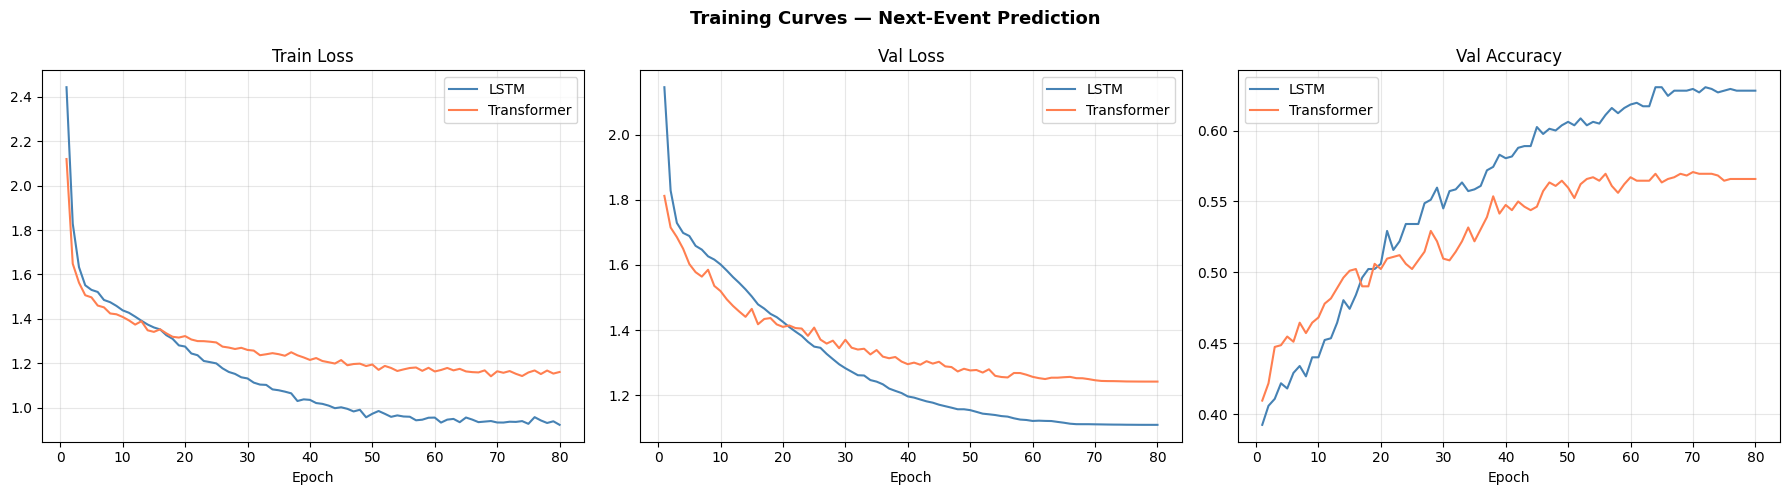

,Model,Best val loss,Best val acc,Epochs run
0,LSTM,1.1087,0.630,80
1,Transformer,1.2416,0.571,80


In [15]:
# ── Plot training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Curves — Next-Event Prediction", fontsize=13, fontweight="bold")

models_hist = {"LSTM": lstm_history, "Transformer": transformer_history}
colours     = {"LSTM": "steelblue", "Transformer": "coral"}

for name, hist in models_hist.items():
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], label=name, color=colours[name])
    axes[1].plot(epochs, hist["val_loss"],   label=name, color=colours[name])
    axes[2].plot(epochs, hist["val_acc"],    label=name, color=colours[name])

for ax, title in zip(axes, ["Train Loss", "Val Loss", "Val Accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
rows = []
for name, hist in models_hist.items():
    rows.append({
        "Model":         name,
        "Best val loss": f"{min(hist['val_loss']):.4f}",
        "Best val acc":  f"{max(hist['val_acc']):.3f}",
        "Epochs run":    len(hist["train_loss"]),
    })
pd.DataFrame(rows)

## Block 10 — Extract User Embeddings (Hidden States)

Now we run each model in **eval mode** over each user's **full 50-event sequence** and extract the embedding vector.

| Model | Embedding source | Shape |
|---|---|---|
| LSTM | Final hidden state `h_T` of top LSTM layer | `(hidden_dim,)` = `(64,)` |
| Transformer | Mean-pool of all output positions | `(d_model,)` = `(64,)` |

We store results in a `DataFrame` with columns `user_id`, `persona`, and one column per embedding dimension.

In [16]:
def extract_embeddings(model, user_full_seqs: Dict[str, List[int]], user_meta) -> pd.DataFrame:
    """
    Run the model encoder over every user's full event sequence.
    Returns a DataFrame: user_id | persona | dim_0 | dim_1 | ...
    """
    records = []
    for user_id, seq in user_full_seqs.items():
        x   = torch.tensor(seq, dtype=torch.long).to(device)
        emb = model.encode(x).cpu().numpy()              # (hidden_dim,)
        row = {"user_id": user_id, "persona": user_meta.loc[user_id, "persona"]}
        row.update({f"dim_{i}": v for i, v in enumerate(emb)})
        records.append(row)
    return pd.DataFrame(records).set_index("user_id")


lstm_emb_df        = extract_embeddings(lstm_model,        user_full_seqs, user_meta)
transformer_emb_df = extract_embeddings(transformer_model, user_full_seqs, user_meta)

print("LSTM embedding matrix shape      :", lstm_emb_df.drop("persona", axis=1).shape)
print("Transformer embedding matrix shape:", transformer_emb_df.drop("persona", axis=1).shape)
print()
print("LSTM embeddings (first 5 dims):")
display(lstm_emb_df[["persona"] + [f"dim_{i}" for i in range(5)]].round(4))

LSTM embedding matrix shape      : (10, 64)
Transformer embedding matrix shape: (10, 64)

LSTM embeddings (first 5 dims):


,persona,dim_0,dim_1,dim_2,dim_3,dim_4
user_id,,,,,,
usr_0000,senior_tax_partner,-0.7942,-0.5283,0.7828,-0.1632,0.8829
usr_0001,junior_tax_associate,-0.8702,-0.2896,0.7589,-0.0974,0.7564
usr_0002,inhouse_tax_counsel,-0.8928,-0.4447,0.7926,-0.1981,0.9016
usr_0003,tax_research_analyst,-0.8308,-0.5116,0.8219,-0.2506,0.9210
usr_0004,ma_tax_specialist,-0.8647,-0.4268,0.8108,-0.2563,0.9158
usr_0005,transfer_pricing_specialist,-0.8219,-0.6159,0.8115,-0.1751,0.9232
usr_0006,tax_technology_manager,-0.9284,-0.3551,0.7875,-0.1590,0.9066
usr_0007,compliance_officer,-0.7800,-0.6034,0.8192,-0.1402,0.9245
usr_0008,tax_litigator,-0.9054,-0.3221,0.7366,-0.0684,0.8011


## Block 11 — Visualise Embeddings with PCA & t-SNE

### Why dimensionality reduction?
Our embedding vectors live in ℝ⁶⁴. We can't visualise 64 dimensions directly.

- **PCA**: linear projection — fast, deterministic, preserves global variance. Good for understanding if the embedding space has a clear structure.
- **t-SNE**: non-linear — optimises for local neighbourhood preservation. Better at revealing clusters but stochastic and slower.

With only 10 users, **don't over-interpret** the plots — they are qualitative. The real signal is whether users with similar personas land near each other.

/var/folders/9p/1bpm8tzn10xf9kv9wby6jmwm0000gn/T/ipykernel_37956/2204001877.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", len(unique_personas))


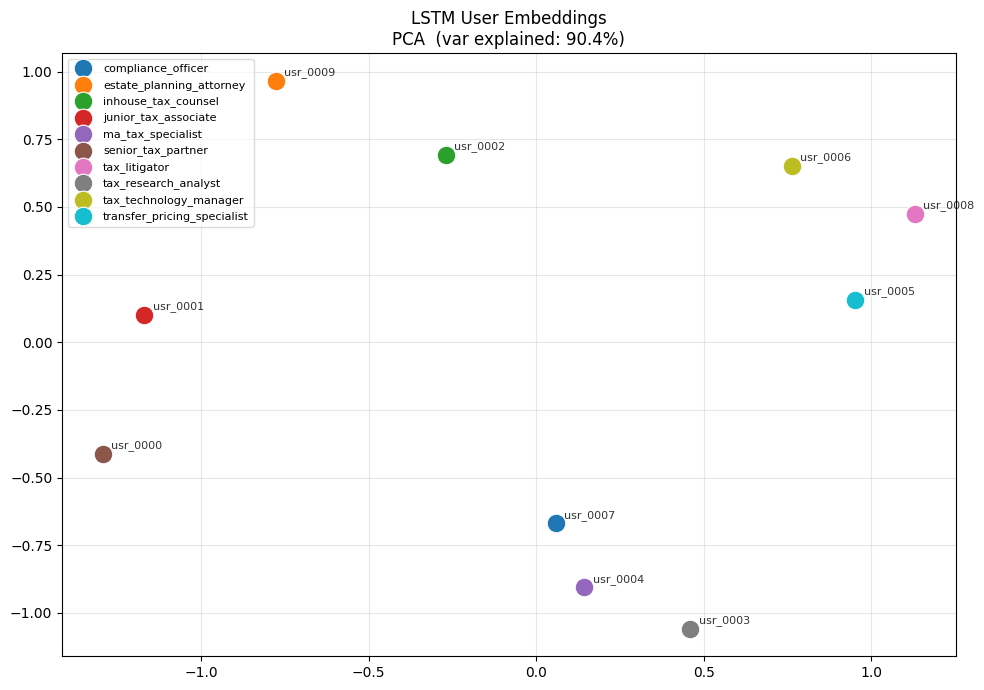

/var/folders/9p/1bpm8tzn10xf9kv9wby6jmwm0000gn/T/ipykernel_37956/2204001877.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", len(unique_personas))


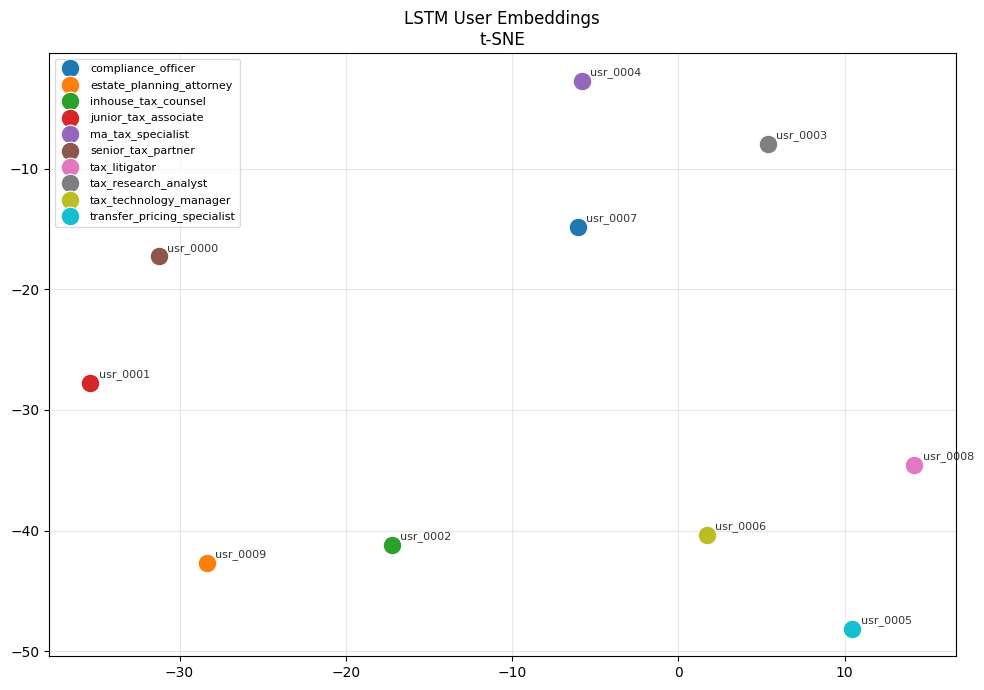

/var/folders/9p/1bpm8tzn10xf9kv9wby6jmwm0000gn/T/ipykernel_37956/2204001877.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", len(unique_personas))


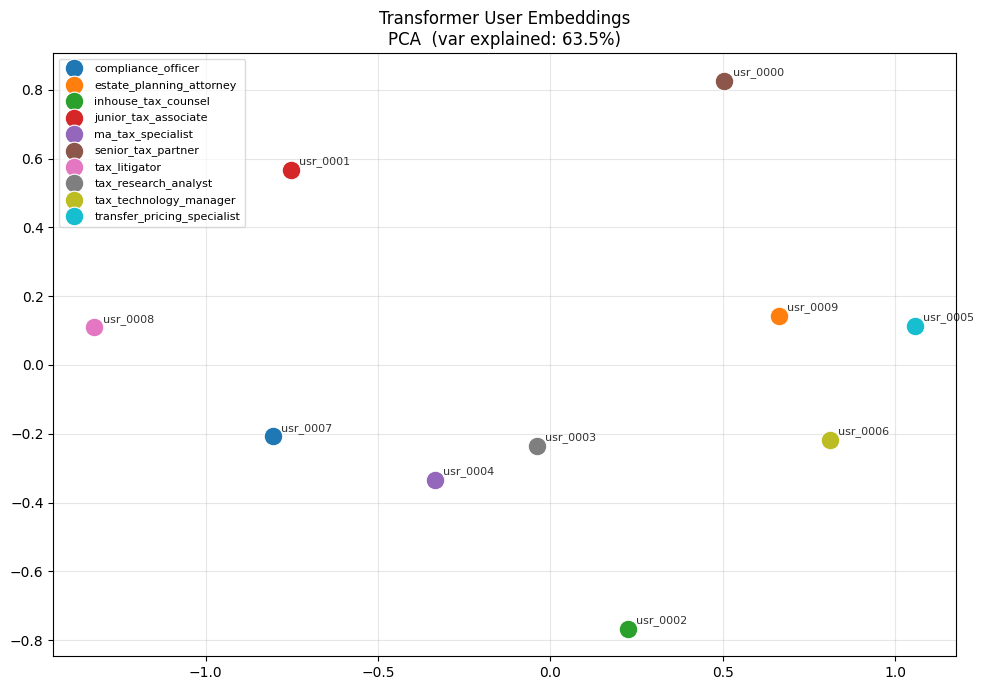

/var/folders/9p/1bpm8tzn10xf9kv9wby6jmwm0000gn/T/ipykernel_37956/2204001877.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", len(unique_personas))


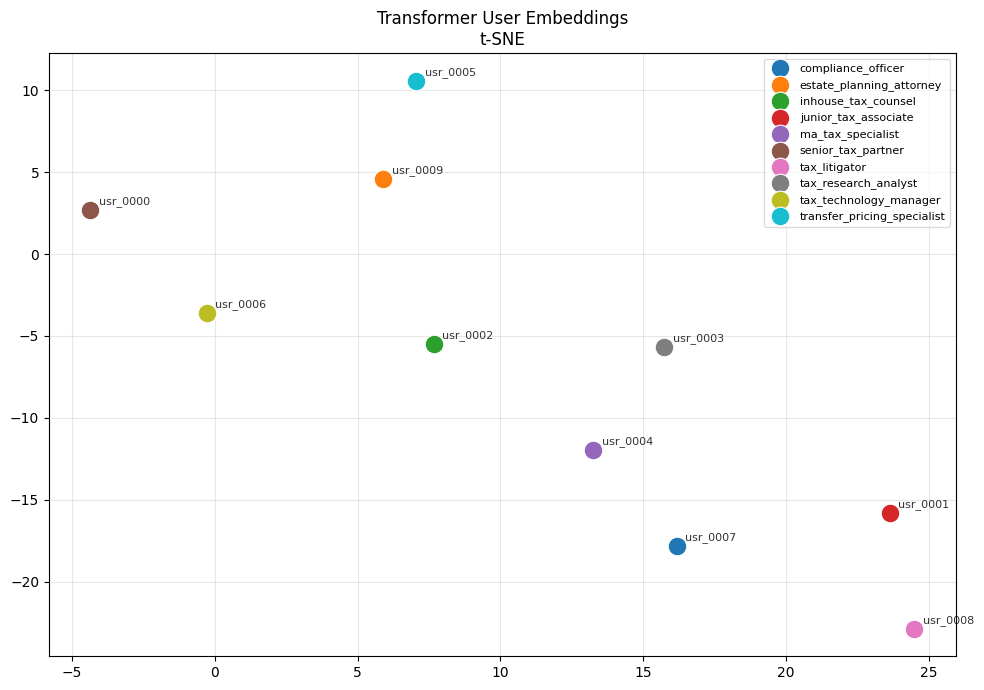

In [17]:
def plot_embeddings_2d(emb_df: pd.DataFrame, title: str, method: str = "pca"):
    """
    Project embeddings to 2D and scatter-plot, coloured by persona.

    method: 'pca' or 'tsne'
    """
    X        = emb_df.drop("persona", axis=1).values.astype(np.float32)
    labels   = emb_df["persona"].values
    user_ids = emb_df.index.tolist()

    if method == "pca":
        reducer = PCA(n_components=2, random_state=SEED)
        coords  = reducer.fit_transform(X)
        method_label = f"PCA  (var explained: {reducer.explained_variance_ratio_.sum():.1%})"
    else:
        perplexity = min(5, len(X) - 1)          # t-SNE perplexity must be < n_samples
        reducer    = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, max_iter=1000)
        coords     = reducer.fit_transform(X)
        method_label = "t-SNE"

    unique_personas = sorted(set(labels))
    palette = cm.get_cmap("tab10", len(unique_personas))
    colour_map = {p: palette(i) for i, p in enumerate(unique_personas)}

    fig, ax = plt.subplots(figsize=(10, 7))
    for persona in unique_personas:
        mask = labels == persona
        ax.scatter(coords[mask, 0], coords[mask, 1], label=persona,
                   color=colour_map[persona], s=180, zorder=3, edgecolors="white", linewidths=0.8)

    # Annotate each point with user_id
    for i, uid in enumerate(user_ids):
        ax.annotate(uid, (coords[i, 0], coords[i, 1]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8, alpha=0.8)

    ax.set_title(f"{title}\n{method_label}", fontsize=12)
    ax.legend(loc="best", fontsize=8, framealpha=0.7)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── LSTM embeddings ────────────────────────────────────────────────────────────
plot_embeddings_2d(lstm_emb_df,        "LSTM User Embeddings",        method="pca")
plot_embeddings_2d(lstm_emb_df,        "LSTM User Embeddings",        method="tsne")

# ── Transformer embeddings ─────────────────────────────────────────────────────
plot_embeddings_2d(transformer_emb_df, "Transformer User Embeddings", method="pca")
plot_embeddings_2d(transformer_emb_df, "Transformer User Embeddings", method="tsne")

## Block 12 — Find Similar Users via Cosine Similarity

### What is cosine similarity?
$$\text{sim}(u, v) = \frac{u \cdot v}{\|u\| \cdot \|v\|}$$

- Range `[-1, 1]`; `1` = identical direction, `0` = orthogonal, `-1` = opposite
- **Scale-invariant**: only the direction of the embedding vector matters, not its magnitude

### What we build
1. A **full pairwise similarity matrix** (10×10 heatmap)
2. A **query function** — given a user, return the top-k most similar users along with their event sequences side-by-side for qualitative inspection

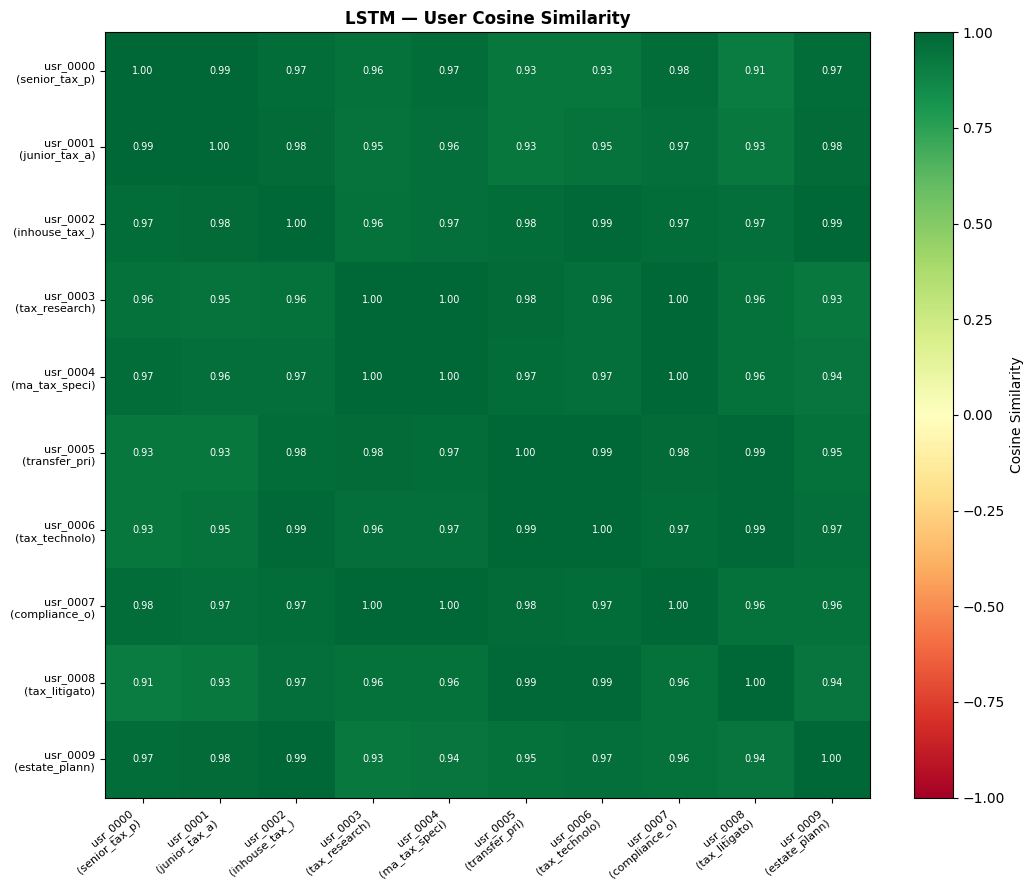

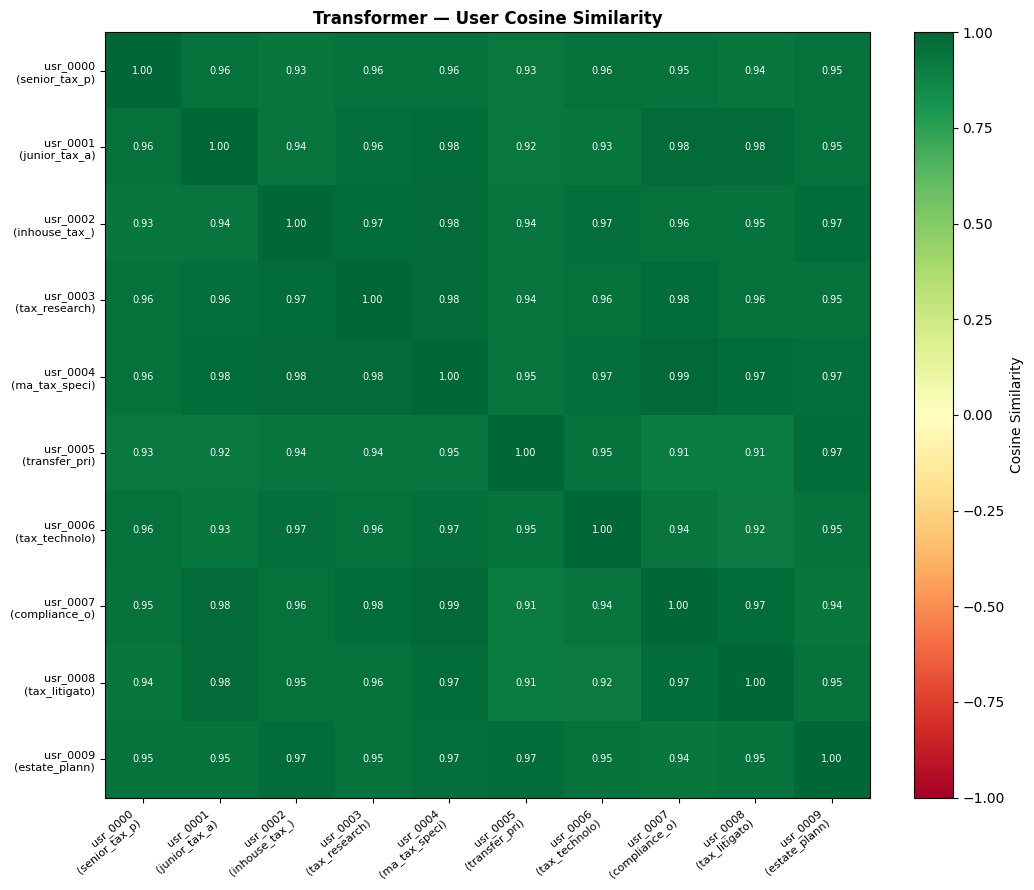

In [18]:
def plot_similarity_heatmap(emb_df: pd.DataFrame, title: str):
    X        = emb_df.drop("persona", axis=1).values.astype(np.float32)
    user_ids = emb_df.index.tolist()
    personas = emb_df["persona"].tolist()
    labels   = [f"{uid}\n({p[:12]})" for uid, p in zip(user_ids, personas)]

    sim_matrix = cosine_similarity(X)

    fig, ax = plt.subplots(figsize=(12, 9))
    im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Cosine Similarity")

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    # Annotate cells
    for i in range(len(user_ids)):
        for j in range(len(user_ids)):
            ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="black" if abs(sim_matrix[i, j]) < 0.7 else "white")

    ax.set_title(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return sim_matrix, user_ids


lstm_sim,        lstm_users        = plot_similarity_heatmap(lstm_emb_df,        "LSTM — User Cosine Similarity")
transformer_sim, transformer_users = plot_similarity_heatmap(transformer_emb_df, "Transformer — User Cosine Similarity")

In [19]:
def find_similar_users(
    query_user: str,
    emb_df: pd.DataFrame,
    model_name: str,
    top_k: int = 3,
    show_sequences: bool = True,
):
    """
    Given a query user, find and display the top-k most similar users
    using cosine similarity on the learned embeddings.
    Also prints their event sequences side-by-side for qualitative comparison.
    """
    X        = emb_df.drop("persona", axis=1).values.astype(np.float32)
    user_ids = emb_df.index.tolist()
    q_idx    = user_ids.index(query_user)

    sim_scores = cosine_similarity(X[q_idx : q_idx + 1], X)[0]   # (n_users,)
    # Exclude self (score = 1.0)
    ranked = sorted(
        [(uid, sim_scores[i]) for i, uid in enumerate(user_ids) if uid != query_user],
        key=lambda x: x[1],
        reverse=True,
    )

    print(f"\n{'='*65}")
    print(f"Model: {model_name}  |  Query user: {query_user}  ({emb_df.loc[query_user, 'persona']})")
    print(f"Top-{top_k} most similar users:")
    print(f"{'='*65}")
    for rank, (uid, score) in enumerate(ranked[:top_k], 1):
        print(f"  #{rank}  {uid}  ({emb_df.loc[uid, 'persona']})  —  cosine sim = {score:.4f}")

    if show_sequences:
        print(f"\nEvent sequences (query → neighbours):")
        print(f"  {'QUERY '+query_user:30s}", end="")
        for uid, _ in ranked[:top_k]:
            print(f"  {'TOP-'+str(ranked.index((uid, _))+1)+' '+uid:30s}", end="")
        print()

        # Align event sequences row-by-row
        query_seq = df[df["user_id"] == query_user].sort_values("sequence_number")["event_type"].tolist()
        nbr_seqs  = [
            df[df["user_id"] == uid].sort_values("sequence_number")["event_type"].tolist()
            for uid, _ in ranked[:top_k]
        ]
        max_len = max(len(query_seq), max(len(s) for s in nbr_seqs))
        for i in range(min(max_len, 20)):   # show first 20 events
            q_evt = query_seq[i] if i < len(query_seq) else ""
            row   = f"  {i+1:2d}. {q_evt:28s}"
            for seq in nbr_seqs:
                evt = seq[i] if i < len(seq) else ""
                # Highlight matching events
                match = "✓" if evt == q_evt and evt != "" else " "
                row  += f"  {match} {evt:28s}"
            print(row)


# ── Run similarity queries ─────────────────────────────────────────────────────
for query in ["usr_0000", "usr_0005"]:
    find_similar_users(query, lstm_emb_df,        model_name="LSTM",        top_k=3)
    find_similar_users(query, transformer_emb_df, model_name="Transformer", top_k=3)


Model: LSTM  |  Query user: usr_0000  (senior_tax_partner)
Top-3 most similar users:
  #1  usr_0001  (junior_tax_associate)  —  cosine sim = 0.9937
  #2  usr_0007  (compliance_officer)  —  cosine sim = 0.9755
  #3  usr_0009  (estate_planning_attorney)  —  cosine sim = 0.9713

Event sequences (query → neighbours):
  QUERY usr_0000                  TOP-1 usr_0001                  TOP-2 usr_0007                  TOP-3 usr_0009                
   1. session_start                 ✓ session_start                 ✓ session_start                 ✓ session_start               
   2. session_start                 ✓ session_start                 ✓ session_start                 ✓ session_start               
   3. session_start                 ✓ session_start                 ✓ session_start                 ✓ session_start               
   4. session_start                 ✓ session_start                 ✓ session_start                 ✓ session_start               
   5. session_start            

## Block 13 — Embedding Quality Analysis: LSTM vs Transformer

### Intra-class vs Inter-class similarity
A good embedding space satisfies:
- **High intra-class similarity**: users with the same persona should be close
- **Low inter-class similarity**: users with different personas should be far apart

We compute the **silhouette-like analysis** manually: average pairwise similarity within the same persona category vs across different categories.

> Note: with 10 unique personas (one user each) there are no true same-persona pairs. We instead use **firm_size** and **org_type** as proxy groupings — these are richer and overlap across users.

In [20]:
def embedding_quality_report(emb_df: pd.DataFrame, sim_matrix: np.ndarray, model_name: str):
    """
    Compute and print intra-group vs inter-group cosine similarity stats
    using firm_size and org_type as grouping variables.
    """
    user_ids  = emb_df.index.tolist()
    n         = len(user_ids)
    uid2meta  = user_meta.loc[user_ids]

    results = []
    for attr in ["firm_size", "org_type"]:
        groups = uid2meta[attr].values
        intra_sims, inter_sims = [], []
        for i in range(n):
            for j in range(i + 1, n):
                s = sim_matrix[i, j]
                if groups[i] == groups[j]:
                    intra_sims.append(s)
                else:
                    inter_sims.append(s)
        results.append({
            "Model":          model_name,
            "Grouping":       attr,
            "Intra-group sim (mean)": f"{np.mean(intra_sims):.4f}" if intra_sims else "N/A",
            "Inter-group sim (mean)": f"{np.mean(inter_sims):.4f}" if inter_sims else "N/A",
            "Gap (intra−inter)":      f"{np.mean(intra_sims) - np.mean(inter_sims):.4f}" if intra_sims else "N/A",
        })
    return pd.DataFrame(results)


q_lstm        = embedding_quality_report(lstm_emb_df,        lstm_sim,        "LSTM")
q_transformer = embedding_quality_report(transformer_emb_df, transformer_sim, "Transformer")

quality_df = pd.concat([q_lstm, q_transformer], ignore_index=True)
print("Embedding Quality — Intra vs Inter Group Similarity")
print("(Positive gap = similar users from same group are closer in embedding space)\n")
display(quality_df)

Embedding Quality — Intra vs Inter Group Similarity
(Positive gap = similar users from same group are closer in embedding space)



,Model,Grouping,Intra-group sim (mean),Inter-group sim (mean),Gap (intra−inter)
0,LSTM,firm_size,0.9664,0.9648,0.0016
1,LSTM,org_type,0.9937,0.9646,0.0291
2,Transformer,firm_size,0.9504,0.9552,-0.0048
3,Transformer,org_type,0.9592,0.9536,0.0056


## Block 15 — Architecture Deep Dive: Encoder vs Decoder for User Behaviour

### The naming confusion in our existing code
Our `TransformerEncoder` class uses PyTorch's `nn.TransformerEncoder` **with a causal mask**. 
That makes it functionally a **GPT-style decoder-only model** — not a bidirectional encoder.  
PyTorch's API naming is about the *building block* (encoder layer = self-attention + FFN), 
not about whether the model is causal or not. The causal mask is what makes it a "decoder" in the NLP sense.

```
What we call "TransformerEncoder" in this notebook
         ↓
  PyTorch nn.TransformerEncoder + causal_mask=True
         ↓
  Functionally: GPT-style decoder-only (causal self-attention)
  Has: self-attention ✓    cross-attention ✗    causal mask ✓
```

### Three distinct architectures compared

```
┌─────────────────────────────────────────────────────────────────────┐
│  Architecture         │ Attention       │ Training obj    │ Use     │
├─────────────────────────────────────────────────────────────────────┤
│  Bidirectional Enc.   │ Full (no mask)  │ Masked Event    │ Embed   │
│  (BERT-style)         │ e1 ↔ e2 ↔ e3   │ Prediction      │ search  │
├─────────────────────────────────────────────────────────────────────┤
│  Causal Decoder-only  │ Causal mask     │ Next-event      │ Both    │
│  (GPT-style) ← ours   │ e1 → e2 → e3   │ prediction      │         │
├─────────────────────────────────────────────────────────────────────┤
│  Encoder-Decoder      │ Enc: full       │ Seq2seq         │ Session │
│  (T5/BART-style)      │ Dec: cross-att  │ generation      │ summary │
│  ❌ Not useful here   │ (needs 2 seqs)  │                 │         │
└─────────────────────────────────────────────────────────────────────┘
```

### Why Encoder-Decoder is NOT the right choice here
The encoder-decoder requires **two separate sequences**: a source (encoder input) and a target (decoder input with cross-attention over encoder output). Our task has only one sequence (the user's event stream). You'd need to artificially split it (e.g. "encode first 25 events, decode next 25") — this creates an arbitrary boundary and wastes the architecture.

### Why Bidirectional Encoder may be better for similarity search
- **Causal decoder**: embedding at position T = "given e₁..eT, what is P(eT+1)?" — it's prediction-focused
- **Bidirectional encoder**: embedding = "what is the holistic pattern of e₁..eT?" — it's representation-focused

For finding similar users based on *overall behaviour*, the bidirectional encoder produces a more balanced summary.

### Training objective for Bidirectional Encoder: Masked Event Prediction (MEP)
Analogous to BERT's Masked Language Modeling:
```
Original:  [session_start, search_query, document_view, alert_create, session_end]
Masked:    [session_start, [MASK],       document_view, [MASK],       session_end]
Loss:      only at masked positions — predict search_query and alert_create
```
Masking rate: 15% of tokens per window (same as BERT).

In [ ]:
# ── Add MASK special token to vocabulary ──────────────────────────────────────
# We need a [MASK] token for Masked Event Prediction (MEP) training.
# Re-building the vocab with the new token — all existing indices are preserved.
MASK_TOKEN = "<MASK>"
if MASK_TOKEN not in token2idx:
    MASK_IDX = len(token2idx)
    token2idx[MASK_TOKEN] = MASK_IDX
    idx2token[MASK_IDX]   = MASK_TOKEN
else:
    MASK_IDX = token2idx[MASK_TOKEN]

VOCAB_SIZE_WITH_MASK = len(token2idx)
print(f"Vocab size (with MASK token): {VOCAB_SIZE_WITH_MASK}")
print(f"MASK index: {MASK_IDX}")


# ── Masked Event Prediction Dataset ───────────────────────────────────────────
class MaskedEventDataset(Dataset):
    """
    Each item: a full-context window where ~15% of tokens are replaced with MASK_IDX.
    The target is the original token at masked positions; PAD_IDX everywhere else
    (so CrossEntropyLoss with ignore_index=PAD_IDX only penalises masked positions).
    """
    MASK_RATE = 0.15

    def __init__(self, inputs: np.ndarray):
        self.inputs = inputs  # raw, un-masked windows

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        original = self.inputs[idx].copy()
        masked   = original.copy()
        target   = np.full_like(original, PAD_IDX)   # PAD everywhere by default

        # Randomly mask ~15% of positions
        for pos in range(len(original)):
            if original[pos] in (PAD_IDX, BOS_IDX, EOS_IDX):
                continue                              # never mask special tokens
            if np.random.random() < self.MASK_RATE:
                target[pos]  = original[pos]         # label = original token
                masked[pos]  = MASK_IDX              # replace input with [MASK]

        return (
            torch.tensor(masked,  dtype=torch.long),
            torch.tensor(target,  dtype=torch.long),
        )


# Use all windows (no causal structure needed — it's a fill-in-the-blank task)
mep_train_ds = MaskedEventDataset(all_inputs[train_idx])
mep_val_ds   = MaskedEventDataset(all_inputs[val_idx])

mep_train_loader = DataLoader(mep_train_ds, batch_size=BATCH_SIZE, shuffle=True)
mep_val_loader   = DataLoader(mep_val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"MEP train windows: {len(mep_train_ds)},  val windows: {len(mep_val_ds)}")

In [ ]:
class BidirectionalTransformerEncoder(nn.Module):
    """
    BERT-style bidirectional Transformer encoder.

    Key difference from our existing TransformerEncoder:
      - NO causal mask  →  every position attends to every other position
      - Trained with Masked Event Prediction (MEP), not next-event prediction
      - Embedding: mean-pool over all positions (holistic session summary)

    Architecture:
      Embedding(vocab+mask, d_model)
        + PositionalEncoding
          → TransformerEncoderLayer × num_layers   (FULL self-attention, no mask)
            → Linear(d_model → vocab_size)          (prediction head for MEP)

    At inference (embedding extraction):
      Same forward pass without the head → mean-pool → user vector ∈ ℝ^d_model
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.3,
        max_len: int = 512,
        pad_idx: int = PAD_IDX,
    ):
        super().__init__()
        self.d_model   = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        # ── No causal mask here — the crucial difference ───────────────────────
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head        = nn.Linear(d_model, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T)  — input with some positions replaced by MASK_IDX
        returns logits: (B, T, vocab_size)
        NOTE: mask=None  →  FULL bidirectional attention (no causal constraint)
        """
        emb = self.pos_enc(self.embedding(x) * math.sqrt(self.d_model))
        out = self.transformer(emb)          # ← NO mask argument  (bidirectional)
        return self.head(out)

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract user embedding: mean-pool over all non-PAD positions.
        x: (B, T) or (T,)
        returns: (B, d_model) or (d_model,)
        """
        self.eval()
        squeeze = x.dim() == 1
        if squeeze:
            x = x.unsqueeze(0)
        emb = self.pos_enc(self.embedding(x) * math.sqrt(self.d_model))
        out = self.transformer(emb)                          # (B, T, d_model)
        # Mean-pool over time, ignoring PAD positions
        pad_mask = (x != PAD_IDX).unsqueeze(-1).float()     # (B, T, 1)
        pooled   = (out * pad_mask).sum(1) / pad_mask.sum(1) # (B, d_model)
        return pooled.squeeze(0) if squeeze else pooled


# ── Instantiate with the expanded vocab (includes MASK token) ─────────────────
bidir_model = BidirectionalTransformerEncoder(
    vocab_size=VOCAB_SIZE_WITH_MASK,   # one extra token for [MASK]
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in bidir_model.parameters())
print(f"Bidirectional Transformer  |  parameters: {total_params:,}")
print()
print("Architecture difference at a glance:")
print(f"  Causal Transformer (existing) : self-attention WITH causal mask → can only look LEFT")
print(f"  Bidirectional Encoder (new)   : self-attention WITHOUT mask     → looks LEFT and RIGHT")

In [ ]:
def train_mep_model(model, name: str, cfg: TrainConfig):
    """
    Train with Masked Event Prediction (MEP).
    Loss is only computed at masked positions (target = PAD_IDX elsewhere).
    """
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)   # ignores non-masked positions
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_loss    = float("inf")
    patience_counter = 0
    best_state       = None

    print(f"\n{'='*60}")
    print(f"Training (MEP): {name}")
    print(f"{'='*60}")

    t0 = time.time()
    for epoch in range(1, cfg.epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        tr_loss_sum, tr_correct, tr_total = 0.0, 0, 0
        for x_masked, y in mep_train_loader:
            x_masked, y = x_masked.to(device), y.to(device)
            logits = model(x_masked)                           # (B, T, V)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE_WITH_MASK), y.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            # Count only masked positions (where target != PAD_IDX)
            mask_positions = (y != PAD_IDX)
            n_masked = mask_positions.sum().item()
            if n_masked > 0:
                preds = logits.argmax(-1)
                tr_correct  += (preds[mask_positions] == y[mask_positions]).sum().item()
                tr_total    += n_masked
                tr_loss_sum += loss.item() * n_masked

        tr_loss = tr_loss_sum / max(tr_total, 1)
        tr_acc  = tr_correct  / max(tr_total, 1)

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x_masked, y in mep_val_loader:
                x_masked, y = x_masked.to(device), y.to(device)
                logits = model(x_masked)
                loss   = criterion(logits.reshape(-1, VOCAB_SIZE_WITH_MASK), y.reshape(-1))
                mask_positions = (y != PAD_IDX)
                n_masked = mask_positions.sum().item()
                if n_masked > 0:
                    preds = logits.argmax(-1)
                    val_correct  += (preds[mask_positions] == y[mask_positions]).sum().item()
                    val_total    += n_masked
                    val_loss_sum += loss.item() * n_masked

        val_loss = val_loss_sum / max(val_total, 1)
        val_acc  = val_correct  / max(val_total, 1)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"  epoch {epoch:3d} | tr_loss {tr_loss:.4f} | "
                f"val_loss {val_loss:.4f} | val_acc(masked) {val_acc:.3f} | "
                f"patience {patience_counter}/{cfg.patience}"
            )
        if patience_counter >= cfg.patience:
            print(f"  ⏹  Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"\n  Best val_loss: {best_val_loss:.4f}  |  Time: {time.time()-t0:.1f}s")
    return history


bidir_history = train_mep_model(bidir_model, "Bidirectional Transformer (MEP)", cfg)

In [ ]:
# ── Compare all three models' training curves ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Curves — All Three Architectures", fontsize=13, fontweight="bold")

all_histories = {
    "LSTM (next-event)":               lstm_history,
    "Causal Transformer (next-event)": transformer_history,
    "Bidirectional Enc. (MEP)":        bidir_history,
}
colours = {
    "LSTM (next-event)":               "steelblue",
    "Causal Transformer (next-event)": "coral",
    "Bidirectional Enc. (MEP)":        "mediumseagreen",
}

for name, hist in all_histories.items():
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"], label=name, color=colours[name])
    axes[1].plot(ep, hist["val_loss"],   label=name, color=colours[name])
    axes[2].plot(ep, hist["val_acc"],    label=name, color=colours[name])

subtitles = [
    "Train Loss",
    "Val Loss",
    "Val Accuracy\n(note: MEP measures masked-position accuracy\n— different task, not directly comparable)",
]
for ax, title in zip(axes, subtitles):
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
summary = []
for name, hist in all_histories.items():
    summary.append({
        "Model":         name,
        "Best val loss": f"{min(hist['val_loss']):.4f}",
        "Best val acc":  f"{max(hist['val_acc']):.3f}",
        "Epochs run":    len(hist["train_loss"]),
    })
pd.DataFrame(summary)

In [ ]:
# ── Extract bidirectional encoder embeddings ───────────────────────────────────
bidir_emb_df = extract_embeddings(bidir_model, user_full_seqs, user_meta)

print("Bidirectional encoder embedding matrix shape:", bidir_emb_df.drop("persona", axis=1).shape)

# ── Side-by-side PCA comparison: all three models ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("User Embeddings — PCA Comparison Across Architectures", fontsize=13, fontweight="bold")

model_embs = {
    "LSTM\n(final hidden state h_T)":                lstm_emb_df,
    "Causal Transformer\n(mean-pool, causal mask)":   transformer_emb_df,
    "Bidirectional Encoder\n(mean-pool, full attn)":  bidir_emb_df,
}

for ax, (title, emb_df) in zip(axes, model_embs.items()):
    X        = emb_df.drop("persona", axis=1).values.astype(np.float32)
    labels   = emb_df["persona"].values
    user_ids = emb_df.index.tolist()

    pca    = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(X)
    var    = pca.explained_variance_ratio_.sum()

    unique_personas = sorted(set(labels))
    palette   = plt.cm.tab10
    cmap_vals = {p: palette(i / max(len(unique_personas)-1, 1)) for i, p in enumerate(unique_personas)}

    for persona in unique_personas:
        mask = labels == persona
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=persona, color=cmap_vals[persona],
                   s=160, zorder=3, edgecolors="white", linewidths=0.8)

    for i, uid in enumerate(user_ids):
        ax.annotate(uid, (coords[i, 0], coords[i, 1]),
                    textcoords="offset points", xytext=(5, 4), fontsize=7, alpha=0.85)

    ax.set_title(f"{title}\n(PCA var explained: {var:.1%})", fontsize=9)
    ax.legend(fontsize=6, loc="best", framealpha=0.7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Cosine similarity heatmap for bidirectional encoder ───────────────────────
bidir_sim, bidir_users = plot_similarity_heatmap(bidir_emb_df, "Bidirectional Encoder — User Cosine Similarity")

# ── Quality comparison across all three models ─────────────────────────────────
q_bidir = embedding_quality_report(bidir_emb_df, bidir_sim, "Bidirectional Encoder (MEP)")
all_quality = pd.concat([q_lstm, q_transformer, q_bidir], ignore_index=True)

print("Embedding Quality — All Three Architectures")
print("Gap > 0 means users in the same group are closer together in embedding space\n")
display(all_quality)

print("\n─── Interpretation ────────────────────────────────────────────────────────")
print("LSTM final h_T          : captures recurrent behavioural momentum")
print("Causal Transformer      : attends to left context only (GPT-style)")
print("Bidirectional Encoder   : attends to full sequence simultaneously (BERT-style)")
print()
print("For SIMILARITY SEARCH: prefer the architecture with the highest positive gap.")
print("For NEXT-EVENT PREDICTION in production: prefer the causal model (no future leakage).")

## Block 14 — Summary & Next Steps

### What we built
| Step | What happened |
|---|---|
| **Tokenisation** | 13 event types → integer vocab (size 17 with special tokens) |
| **Sliding window** | 10 users × 50 events → ~410 (input, target) window pairs |
| **Training objective** | Next-event prediction (causal language model) |
| **LSTM encoder** | Embedding → 2-layer LSTM → final hidden state `h_T` ∈ ℝ⁶⁴ |
| **Transformer encoder** | Embedding + Pos.Enc. → 2-layer self-attention → mean-pool ∈ ℝ⁶⁴ |
| **User embeddings** | Each user → 1 vector summarising their full behavioural trajectory |
| **Similarity search** | Cosine similarity over embeddings → nearest-neighbour retrieval |

### Interpreting the embeddings
- If the cosine similarity heatmap shows **block structure** (users with similar org_type or firm_size clustering) → the model learned meaningful behavioural patterns
- A **positive intra-group vs inter-group gap** in Block 13 confirms the embedding space is discriminative

### Limitations of this experiment
| Issue | Impact | Remedy |
|---|---|---|
| Only 10 users | Embeddings will overfit to individual trajectories | Generate more users (`--n-personas 100`) |
| 50 events per user | Short sequences — limited behavioural signal | Increase `--events-per-persona` |
| Only `event_type` used | Ignores rich `event_properties` (doc type, query text) | Build compound tokens or add side features |
| No temporal features | Order is used but timestamps are ignored | Add time-delta embeddings |

### Recommended next steps
1. **Scale the data**: run `python -m data_gen.generate --n-personas 100 --events-per-persona 200`
2. **Add compound tokens**: `event_type + doc_type` from `event_properties` for richer vocab
3. **Add time-delta features**: encode the gap between consecutive events as a continuous feature concatenated to the event embedding
4. **User-level evaluation**: hold out 20% of users completely from training, verify embeddings generalise to unseen personas
5. **FAISS index**: replace brute-force cosine with a FAISS IVF index for sub-millisecond retrieval at scale